In [1]:
using Pkg
Pkg.activate("TASEP")
Pkg.instantiate()
include("./modules/transcription.jl")

  Activating project at `C:\Users\ChemeGrad2021\Documents\Braatz Group\MRNA Synthesis\Published code\IVTratelaw\TASEP`


plotparametricellipse (generic function with 1 method)

The purpose of this notebook is to demostrate the MBDOE workflow we used in designing our experiements. We are showing how three experiments can be used to identify the three kinetic parameters of the initiation-elongation model (in practice we only did two experiments and had a Bayesian prior for K_MD, as described in the main text).

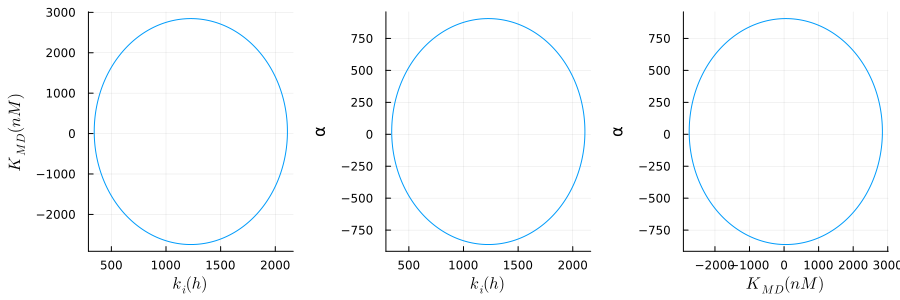

In [2]:
#Basic sequence parameters
N_all = 4243;
N_plasmid = 6082;
initiationlimited = InitiationLimitedModel()
initiationelongation = InitiationElongationModel()
basicTASEP = BasicTASEPModel()
longTASEP = LPTASEPModel();
(p_base,modellist,modelnamelist) = getbaseparams(N_all)

#First we are designing a extremely large prior covariance (using prior = zeros(2,2) leads to numerical overshoot problems)
p_hypothesis = ComponentVector((k_i = 1227.1, α = N_all/2117*10.638962561438944, K = 50, γ = 0, L = 25, N_all = N_all))
p_thinhypothesis = [1227.1, 50, N_all/2117*10.638962561438944]
COVIDpriorcov = [[100000,0,0] [0,1000000,0] [0,0,100000]]
plteCOVIDprior = plotparametricellipse(p_thinhypothesis,COVIDpriorcov)
display(plteCOVIDprior)

got 857218.1282237001 at [35.56511845810225, 5.787863908410816, 6.22565603980486, 128.2245005108486, 124.90304503465597, 752.5304932982016] (returned FTOL_REACHED)


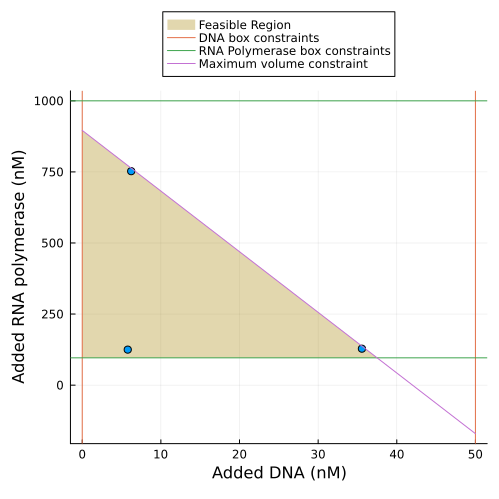

In [7]:
# Performing optimization for MBDOE. Our feasibility region is bounded by a maximum total volume of catalyst 
# (ie RNA polymerase and DNA stock solutions) that could be added to the IVT reaction. The point on the upper left represents
# an initiation-limited regime, the point on the lower right represents and elongation-limited regime, and the lower left point
# helps estimate K_MD. 
nexperiments = 3
COVIDkwargs = (upperDNA = 50, lowerDNA = 0.0001, upperP = 1000, lowerP = 96.0, DNAconcentration = 150, T7concentration = 3200, maxvolumeratio = 0.28)
noisefunc = (T7,DNA,param,base_params)-> exponentialnoise(T7,DNA,param,base_params,initiationelongation,0.032)
(minf,minx,ret) = multistartMBDOEoptimization(initiationelongation,p_thinhypothesis, p_base,nexperiments; noise = noisefunc, priormatrix = inv(COVIDpriorcov), COVIDkwargs...,npoints = 10000)
mbdoeDP = reshape(minx,(nexperiments,2))
plotonboxconstraints(mbdoeDP;COVIDkwargs...) 

<h1>In Silico Validating MBDOE Strategy<h1>

got a residual of 0.0 at [1256.2326370294581, 39.611518763596855, 26.31295141093801] (returned FTOL_REACHED)
got a BIC of 3.3


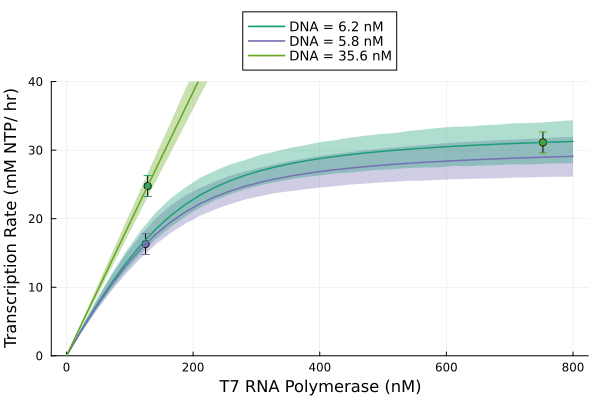

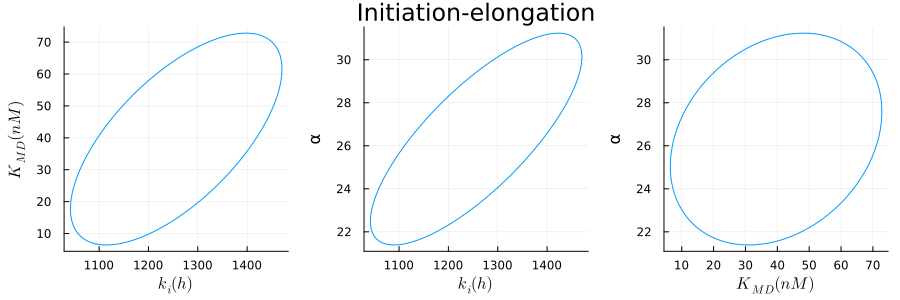

In [8]:
# Validating MBDOE strategy by fitting model to synthetic data
# We get identifiable confidence bounds for k_i and alpha, but uncertainty for K_MD is very high
# This has to do this the high RNAP and DNA concentrations used in our work, as well as 
# The error uncertainty profile for our experiments. For this reason we used a Bayesian prior for K_MD
# Rather than trying to quantify with our kinetic experiments. K_MD is easier to quantify when it is higher (ie high salt concentrations)

DPinputs = mbdoeDP

truemodelindex = 2
truemodel = modellist[truemodelindex]
truemodelname = modelnamelist[truemodelindex]
extraDNA = []


experimentalnoise = [noisefunc(DPinputs[exptind,1],DPinputs[exptind,2],p_hypothesis,p_base) for exptind in 1:size(DPinputs)[1]]
npoints = 10000
normalizexaxis = false
normalizeyaxis = false

(plt,syntheticdata,DPinputs) = generateplotsyntheticdata(truemodel,p_hypothesis,DPinputs,normalizexaxis = normalizexaxis, normalizeyaxis = normalizeyaxis, noise = experimentalnoise, modelname= truemodelname, color = :Dark2_5, extraDNA = extraDNA)

(p_null,p_thintrue,truecov) = multistartoptimizeparams(truemodel, syntheticdata, DPinputs, experimentalnoise, p_base, npoints = npoints)
plotmodelprediction!(plt,truemodel,p_thintrue,truecov,p_base,DPinputs,normalizexaxis = normalizexaxis,normalizeyaxis =normalizeyaxis, modelname = truemodelname, maximumT7 = 800, color =  :Dark2_5, showuncertainty = true, extraDNA = extraDNA)
plot!(legend = :outertop, ylims = (0,Inf))
plot!(ylims = (0,40))
display(plt)
pltelps1 = plotparametricellipse(p_thintrue,truecov,title = truemodelname)
display(pltelps1)